In [34]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [57]:
df = pd.read_csv("adult.csv")
X = df.drop(columns=["income" , "fnlwgt" , "race"])
y = df["income"]

In [15]:
df.head(20)

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,Private,77053,HS-grad,9,Widowed,Prof-specialty,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,Private,186061,Some-college,10,Widowed,Prof-specialty,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
5,34,Private,216864,HS-grad,9,Divorced,Other-service,Unmarried,White,Female,0,3770,45,United-States,<=50K
6,38,Private,150601,10th,6,Separated,Adm-clerical,Unmarried,White,Male,0,3770,40,United-States,<=50K
7,74,State-gov,88638,Doctorate,16,Never-married,Prof-specialty,Other-relative,White,Female,0,3683,20,United-States,>50K
8,68,Federal-gov,422013,HS-grad,9,Divorced,Prof-specialty,Not-in-family,White,Female,0,3683,40,United-States,<=50K
9,41,Private,70037,Some-college,10,Never-married,Craft-repair,Unmarried,White,Male,0,3004,60,United-States,>50K


# Data cleaning

In [61]:
categorical_cols = X.select_dtypes(include="object").columns
for col in categorical_cols:
    most_frequent = X[X[col] != '?'][col].mode()[0]
    X[col] = X[col].replace('?' , most_frequent)

C:\Users\avira\AppData\Local\Temp\ipykernel_38944\841664490.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include="object").columns


In [54]:
df

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,Private,77053,HS-grad,9,Widowed,Prof-specialty,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,Private,186061,Some-college,10,Widowed,Prof-specialty,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K


In [62]:
test_numerical_cols = X.select_dtypes(include = 'number')
test_categorical_cols = X.select_dtypes(include = 'object')

C:\Users\avira\AppData\Local\Temp\ipykernel_38944\2565500870.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  test_categorical_cols = X.select_dtypes(include = 'object')


In [63]:
test_categorical_cols

,workclass,education,marital.status,occupation,relationship,sex,native.country
0,Private,HS-grad,Widowed,Prof-specialty,Not-in-family,Female,United-States
1,Private,HS-grad,Widowed,Exec-managerial,Not-in-family,Female,United-States
2,Private,Some-college,Widowed,Prof-specialty,Unmarried,Female,United-States
3,Private,7th-8th,Divorced,Machine-op-inspct,Unmarried,Female,United-States
4,Private,Some-college,Separated,Prof-specialty,Own-child,Female,United-States
...,...,...,...,...,...,...,...
32556,Private,Some-college,Never-married,Protective-serv,Not-in-family,Male,United-States
32557,Private,Assoc-acdm,Married-civ-spouse,Tech-support,Wife,Female,United-States
32558,Private,HS-grad,Married-civ-spouse,Machine-op-inspct,Husband,Male,United-States
32559,Private,HS-grad,Widowed,Adm-clerical,Unmarried,Female,United-States


# EDA(exploratiory data analysis)

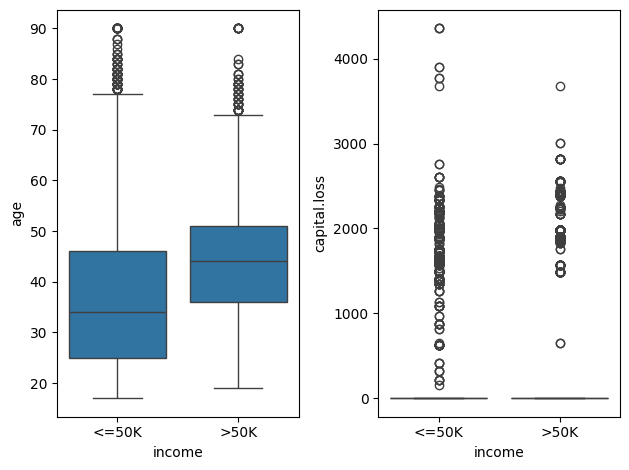

In [41]:
#outlier if any
fig , axes = plt.subplots(1,2)
sns.boxplot(data = df , x = 'income' , y = 'age' , ax = axes[0])
sns.boxplot(data = df , x = 'income' , y = 'capital.loss' , ax = axes[1])

plt.tight_layout()

# encoding 

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
X["workclass"] = le.fit_transform(X["workclass"])
X["education"] = le.fit_transform(X["education"])
X["occupation"] = le.fit_transform(X["occupation"])


In [67]:
from sklearn.preprocessing import OneHotEncoder


cols = ["marital.status" , "relationship" , "sex" , "native.country"]
ohe = OneHotEncoder(sparse_output = False , drop = "first" , handle_unknown = "ignore" )

encoded = ohe.fit_transform(df[cols])

encoded_df = pd.DataFrame(encoded , columns = ohe.get_feature_names_out(cols) , index = df.index)
X = pd.concat([X.drop(columns = cols) , encoded_df] , axis = 1)

In [68]:
X

,age,workclass,education,education.num,occupation,capital.gain,capital.loss,hours.per.week,marital.status_Married-AF-spouse,marital.status_Married-civ-spouse,...,native.country_Portugal,native.country_Puerto-Rico,native.country_Scotland,native.country_South,native.country_Taiwan,native.country_Thailand,native.country_Trinadad&Tobago,native.country_United-States,native.country_Vietnam,native.country_Yugoslavia
0,90,3,11,9,9,0,4356,40,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,82,3,11,9,3,0,4356,18,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,66,3,15,10,9,0,4356,40,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,54,3,5,4,6,0,3900,40,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,41,3,15,10,9,0,3900,40,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,3,15,10,10,0,0,40,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
32557,27,3,7,12,12,0,0,38,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
32558,40,3,11,9,6,0,0,40,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
32559,58,3,11,9,0,0,0,40,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


# train test split and scaling 

In [76]:
from sklearn.model_selection import train_test_split

X_train , X_test ,y_train , y_test = train_test_split(X , y , test_size= 0.2 , random_state = 42)
# Encode target variable
le_target = LabelEncoder()
y_train_encoded = le_target.fit_transform(y_train)
y_test_encoded = le_target.transform(y_test)


In [77]:
X_train.head()

,age,workclass,education,education.num,occupation,capital.gain,capital.loss,hours.per.week,marital.status_Married-AF-spouse,marital.status_Married-civ-spouse,...,native.country_Portugal,native.country_Puerto-Rico,native.country_Scotland,native.country_South,native.country_Taiwan,native.country_Thailand,native.country_Trinadad&Tobago,native.country_United-States,native.country_Vietnam,native.country_Yugoslavia
5514,26,3,11,9,2,0,0,25,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
19777,24,3,11,9,7,0,0,35,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
10781,36,3,9,13,0,0,0,40,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
32240,22,6,15,10,0,0,0,20,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
9876,31,1,9,13,9,0,0,40,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [71]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [87]:
#kNN
from sklearn.neighbors import KNeighborsClassifier


knn = KNeighborsClassifier(n_neighbors=31)
knn.fit(X_train_scaled, y_train_encoded)

y_train_prt = knn.predict(X_train_scaled)
y_test_prt = knn.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import r2_score
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder



y_train_prt = knn.predict(X_train_scaled)
y_test_prt = knn.predict(X_test_scaled)

print("accuracy training : " , accuracy_score(y_train_encoded , y_train_prt) * 100 , "%")
print("accuray testing : " , accuracy_score(y_test_encoded , y_test_prt) * 100 , "%")

r2 score training :  16.18426519346108 %
r2 score testing :  10.072865041725343 %
accuracy training :  84.62453931203932 %
accuray testing :  83.78627360663289 %


In [89]:
#naive baye's
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()
gnb.fit(X_train_scaled, y_train_encoded)
y_train_prt = gnb.predict(X_train_scaled)
y_test_prt = gnb.predict(X_test_scaled)

y_train_prt = gnb.predict(X_train_scaled)
y_test_prt = gnb.predict(X_test_scaled)

print("accuracy training : " , accuracy_score(y_train_encoded , y_train_prt) * 100 , "%")
print("accuray testing : " , accuracy_score(y_test_encoded , y_test_prt) * 100 , "%")

accuracy training :  49.50092137592137 %
accuray testing :  48.91754951635191 %


In [ ]:
#decision tree
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth = 12)

dt.fit(X_train_scaled, y_train_encoded)
y_train_prt = dt.predict(X_train_scaled)
y_test_prt = dt.predict(X_test_scaled)

print("accuracy training : " , accuracy_score(y_train_encoded , y_train_prt) * 100 , "%")
print("accuray testing : " , accuracy_score(y_test_encoded , y_test_prt) * 100 , "%")

accuracy training :  86.91262285012284 %
accuray testing :  85.9972362966375 %


In [ ]:
# post pruning
path = dt.cost_complexity_pruning_path(X_train_scaled, y_train_encoded)

ccp_alphas = path.ccp_alphas

[0.         0.         0.         ... 0.01570657 0.02944855 0.07318914]


In [107]:
for alpha in ccp_alphas:
    model =  DecisionTreeClassifier(ccp_alpha=alpha)
    y_train_prt = dt.predict(X_train_scaled)
    y_test_prt = dt.predict(X_test_scaled)

    print("accuracy training : " , accuracy_score(y_train_encoded , y_train_prt) * 100 , "%" "for alpha : ", alpha)
    print("accuray testing : " , accuracy_score(y_test_encoded , y_test_prt) * 100 , "%")
    

accuracy training :  97.58522727272727 %for alpha :  0.0
accuray testing :  81.32964839551666 %
accuracy training :  97.58522727272727 %for alpha :  0.0
accuray testing :  81.32964839551666 %
accuracy training :  97.58522727272727 %for alpha :  0.0
accuray testing :  81.32964839551666 %
accuracy training :  97.58522727272727 %for alpha :  0.0
accuray testing :  81.32964839551666 %
accuracy training :  97.58522727272727 %for alpha :  0.0
accuray testing :  81.32964839551666 %
accuracy training :  97.58522727272727 %for alpha :  0.0
accuray testing :  81.32964839551666 %
accuracy training :  97.58522727272727 %for alpha :  0.0
accuray testing :  81.32964839551666 %
accuracy training :  97.58522727272727 %for alpha :  0.0
accuray testing :  81.32964839551666 %
accuracy training :  97.58522727272727 %for alpha :  0.0
accuray testing :  81.32964839551666 %
accuracy training :  97.58522727272727 %for alpha :  0.0
accuray testing :  81.32964839551666 %
accuracy training :  97.58522727272727 %

In [94]:
#random forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=1001,
    oob_score=True,
)

rf.fit(X_train_scaled, y_train_encoded)
y_test_prt = rf.predict(X_test_scaled)

print("accuray testing : " , accuracy_score(y_test_encoded , y_test_prt) * 100 , "%")
print("oob score" , rf.oob_score_ * 100 , "%")


accuray testing :  84.92246276677415 %
oob score 84.90095208845209 %


In [95]:
#bagging of knn

from sklearn.ensemble import BaggingClassifier

bagging = BaggingClassifier(
    knn,
    n_estimators=11
)

bagging.fit(X_train_scaled, y_train_encoded)
y_train_prt = bagging.predict(X_train_scaled)
y_test_prt = bagging.predict(X_test_scaled)

y_train_prt = bagging.predict(X_train_scaled)
y_test_prt = bagging.predict(X_test_scaled)

print("accuracy training : " , accuracy_score(y_train_encoded , y_train_prt) * 100 , "%")
print("accuray testing : " , accuracy_score(y_test_encoded , y_test_prt) * 100 , "%")

accuracy training :  84.60918304668304 %
accuray testing :  83.43313373253493 %


In [111]:
# gradient boosting
from sklearn.ensemble import GradientBoostingClassifier

gbc = GradientBoostingClassifier(
    n_estimators=1001,
    learning_rate = 0.05
)

gbc.fit(X_train_scaled, y_train_encoded)
y_train_prt = gbc.predict(X_train_scaled)
y_test_prt = gbc.predict(X_test_scaled)

y_train_prt = gbc.predict(X_train_scaled)
y_test_prt = gbc.predict(X_test_scaled)

print("accuracy training : " , accuracy_score(y_train_encoded , y_train_prt) * 100 , "%")
print("accuray testing : " , accuracy_score(y_test_encoded , y_test_prt) * 100 , "%")


accuracy training :  88.35611179361179 %
accuray testing :  87.44050360816827 %


In [115]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# SVC model
svc = SVC()

# Fit on X_train_scaled, normal y_train
svc.fit(X_train_scaled, y_train_encoded)

# Predictions
y_train_pred = svc.predict(X_train_scaled)
y_test_pred = svc.predict(X_test_scaled)

# Accuracy
print("accuracy training :", accuracy_score(y_train_encoded, y_train_pred) * 100, "%")
print("accuracy testing :", accuracy_score(y_test_encoded, y_test_pred) * 100, "%")

accuracy training : 84.7972972972973 %
accuracy testing : 84.18547520343928 %


In [116]:
from sklearn.ensemble import StackingClassifier

stacking = StackingClassifier(
    estimators = [
        ("knn" ,knn),
        ("nb" , gnb),
        ("dt",dt),
        ("svc" , svc)
    ],
    cv =5
)

stacking.fit(X_train_scaled, y_train_encoded)
y_train_prt = stacking.predict(X_train_scaled)
y_test_prt = stacking.predict(X_test_scaled)

y_train_prt = stacking.predict(X_train_scaled)
y_test_prt = stacking.predict(X_test_scaled)

print("accuracy training : " , accuracy_score(y_train_encoded , y_train_prt) * 100 , "%")
print("accuray testing : " , accuracy_score(y_test_encoded , y_test_prt) * 100 , "%")

accuracy training :  87.1122542997543 %
accuray testing :  86.44249961615232 %
